<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/LGBT_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('lgbtq_rights_by_country.csv')
df.head(11)

,Territory,Same-sex sexual activity,Recognition of same-sex unions,Same-sex marriage,Adoption by same-sex couples,LGBT people allowed to serve openly in military?,Anti-discrimination laws concerning sexual orientation,Laws concerning gender identity/expression
0,Benin,Yes,No,No,No,Unknown,No,Unknown
1,Burkina Faso,Yes,No,No,No,Unknown,No,Unknown
2,Cape Verde,Yes,No,No,No,Unknown,Yes,Unknown
3,Gambia,No,No,No,No,No,No,No
4,Ghana,No,No,No,No,No,No,No
5,Guinea,No,No,No,No,No,No,No
6,Guinea-Bissau,Yes,No,No,No,Unknown,No,Unknown
7,Ivory Coast,Yes,No,No,No,Unknown,No,Unknown
8,Liberia,No,No,No,No,No,No,No
9,Mali,No,No,No,No,Unknown,No,No


In [3]:
df.tail(11)

,Territory,Same-sex sexual activity,Recognition of same-sex unions,Same-sex marriage,Adoption by same-sex couples,LGBT people allowed to serve openly in military?,Anti-discrimination laws concerning sexual orientation,Laws concerning gender identity/expression
228,Monaco,Yes,Yes,No,No,Yes,Yes,Unknown
229,Netherlands,Yes,Yes,Yes,Yes,Yes,Yes,Yes
230,United Kingdom,Yes,Yes,Yes,Yes,Yes,Yes,Yes
231,Australia Islands and Norfolk Island,Yes,Yes,Yes,Yes,Yes,Yes,Yes
232,New Zealand,Yes,Yes,Yes,Yes,Yes,Yes,Yes
233,Fiji,Yes,No,No,No,Unknown,Yes,Unknown
234,Indonesia,Yes,No,No,No,No,Yes,Yes
235,New Caledonia,Yes,Yes,Yes,Yes,Yes,Yes,Yes
236,Papua New Guinea,No,No,No,No,No,No,No
237,Solomon Islands,No,No,No,No,Unknown,No,No


In [4]:
df.shape

(239, 8)

In [5]:
df.columns

Index(['Territory', 'Same-sex sexual activity',
       'Recognition of same-sex unions', 'Same-sex marriage',
       'Adoption by same-sex couples',
       'LGBT people allowed to serve openly in military?',
       'Anti-discrimination laws concerning sexual orientation',
       'Laws concerning gender identity/expression'],
      dtype='object')

In [6]:
df.dtypes

,0
Territory,object
Same-sex sexual activity,object
Recognition of same-sex unions,object
Same-sex marriage,object
Adoption by same-sex couples,object
LGBT people allowed to serve openly in military?,object
Anti-discrimination laws concerning sexual orientation,object
Laws concerning gender identity/expression,object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 8 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   Territory                                               239 non-null    object
 1   Same-sex sexual activity                                239 non-null    object
 2   Recognition of same-sex unions                          239 non-null    object
 3   Same-sex marriage                                       239 non-null    object
 4   Adoption by same-sex couples                            239 non-null    object
 5   LGBT people allowed to serve openly in military?        239 non-null    object
 6   Anti-discrimination laws concerning sexual orientation  239 non-null    object
 7   Laws concerning gender identity/expression              239 non-null    object
dtypes: object(8)
memory usage: 15.1+ KB


In [8]:
df.describe(include = 'all')

,Territory,Same-sex sexual activity,Recognition of same-sex unions,Same-sex marriage,Adoption by same-sex couples,LGBT people allowed to serve openly in military?,Anti-discrimination laws concerning sexual orientation,Laws concerning gender identity/expression
count,239,239,239,239,239,239,239,239
unique,227,3,2,2,3,3,3,3
top,Georgia,Yes,No,No,No,Yes,Yes,Yes
freq,2,185,156,171,159,110,140,113


In [9]:
df.isnull().sum()

,0
Territory,0
Same-sex sexual activity,0
Recognition of same-sex unions,0
Same-sex marriage,0
Adoption by same-sex couples,0
LGBT people allowed to serve openly in military?,0
Anti-discrimination laws concerning sexual orientation,0
Laws concerning gender identity/expression,0


In [10]:
df.duplicated().sum()

np.int64(12)

# Handling Outliers

In [16]:
df['Anti-discrimination laws concerning sexual orientation'] = pd.to_numeric(df['Anti-discrimination laws concerning sexual orientation'], errors='coerce')

Q1 = df['Anti-discrimination laws concerning sexual orientation']
Q3 = df['Anti-discrimination laws concerning sexual orientation']

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Anti-discrimination laws concerning sexual orientation'] >= lower_bound) & (df['Anti-discrimination laws concerning sexual orientation'] <= upper_bound)].copy()

print("Number of Outliers:", len(df))
print("Number of Outliers:", len(df_outliers))

Number of Outliers: 239
Number of Outliers: 0


# Univarite Analysis

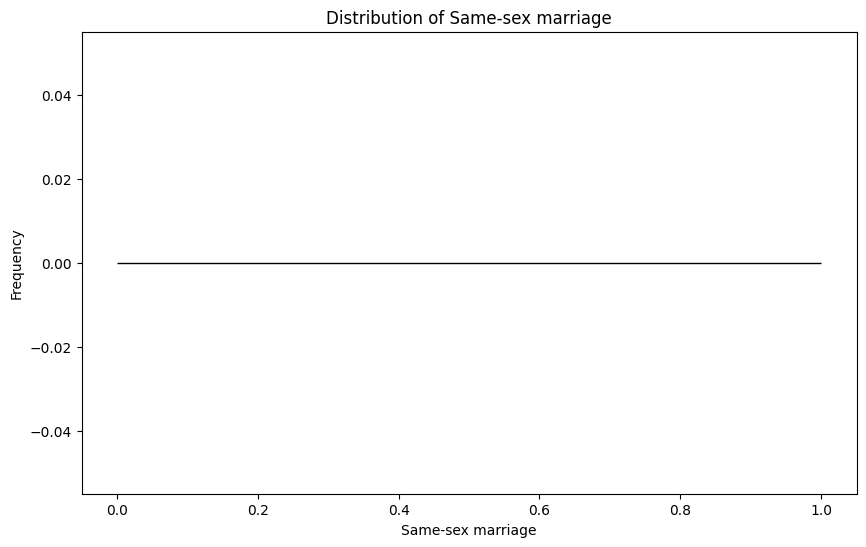

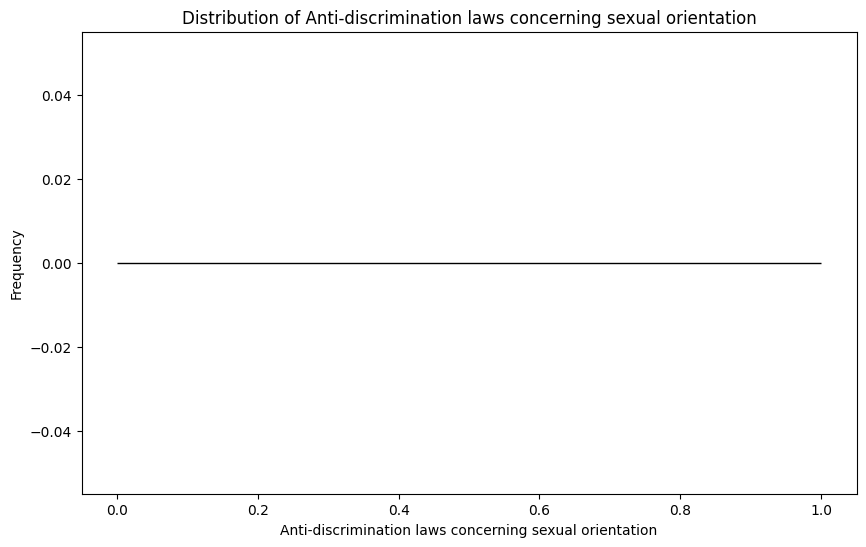

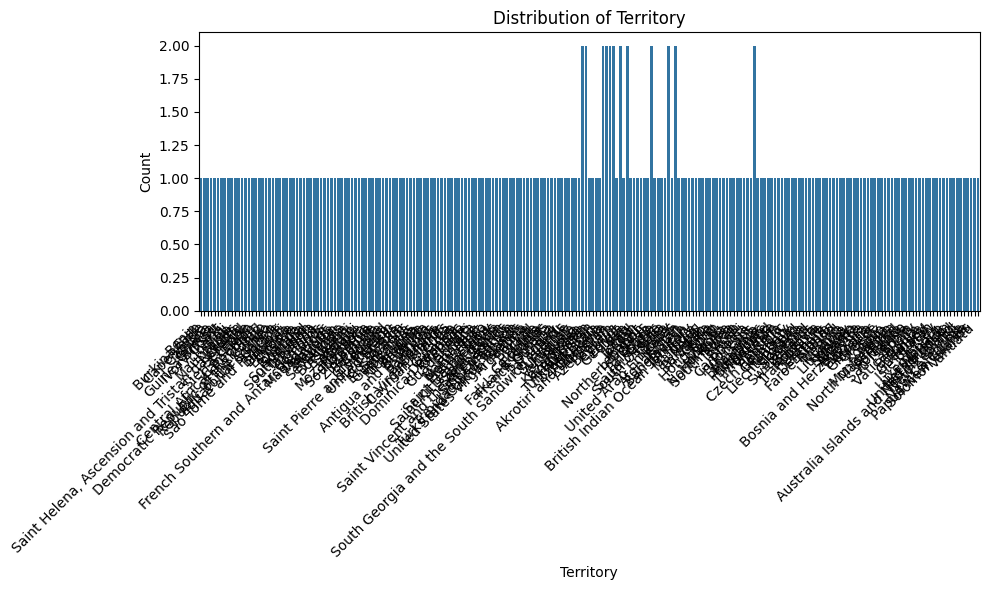

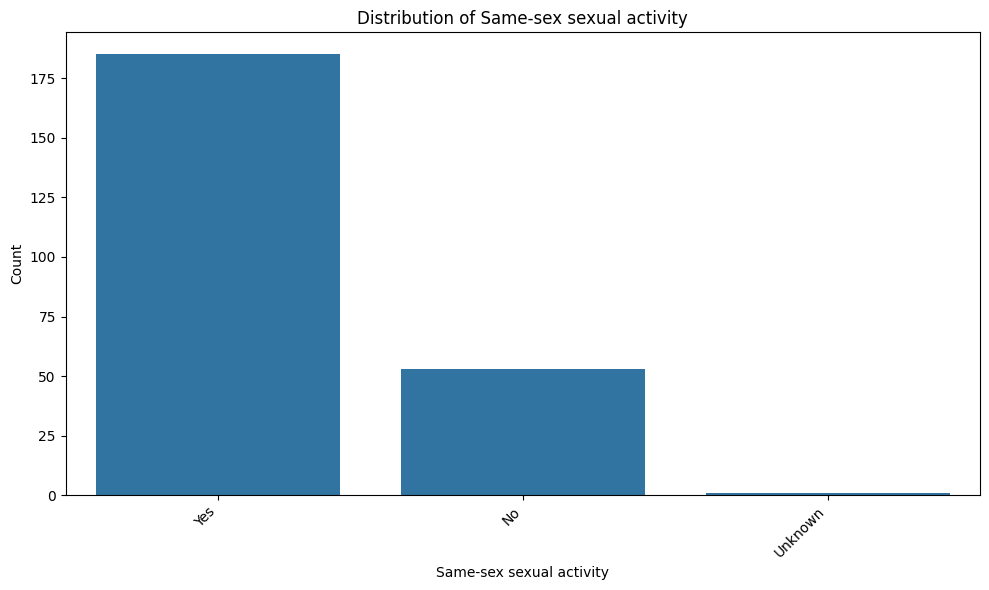

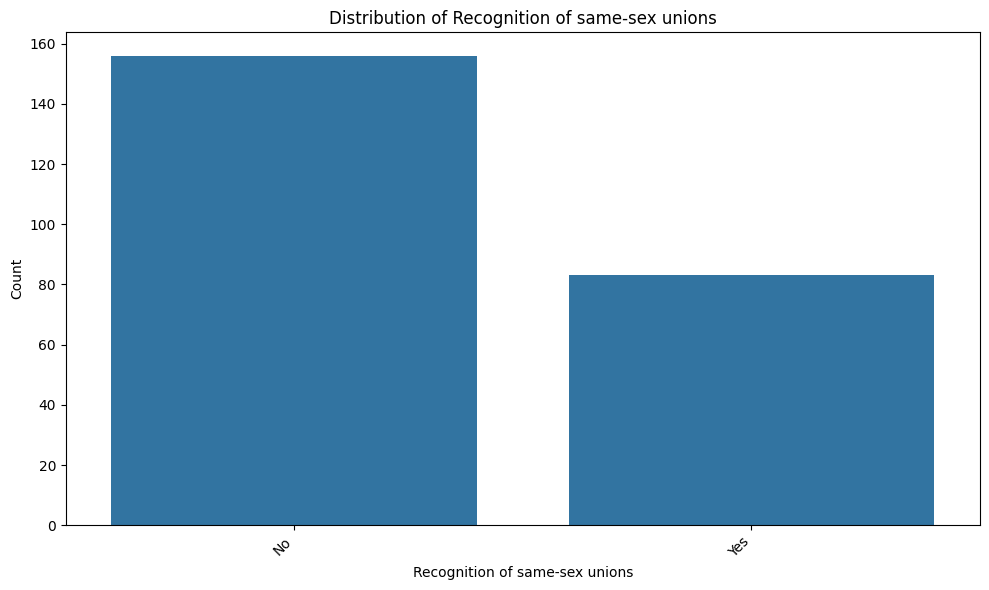

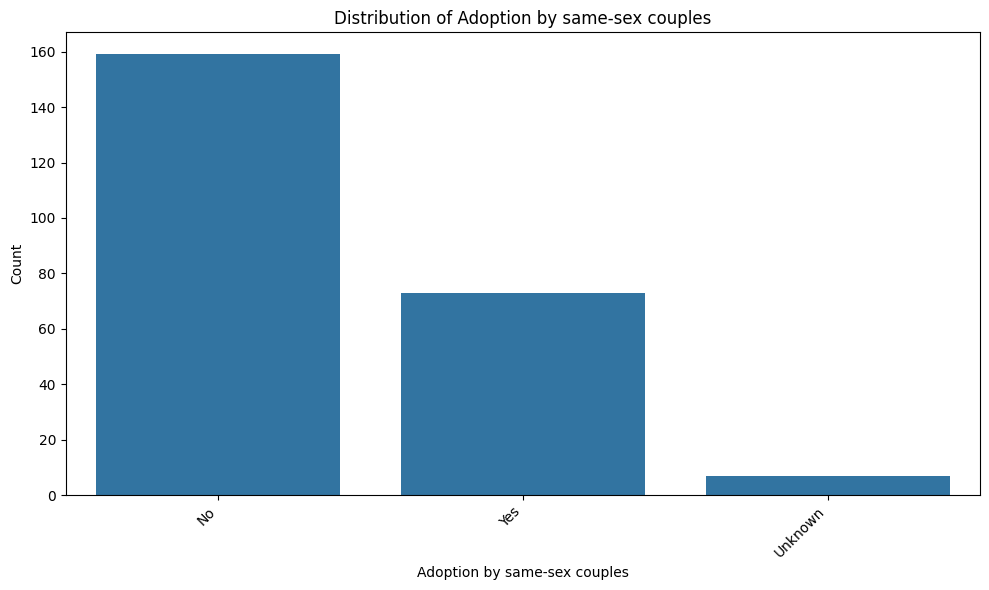

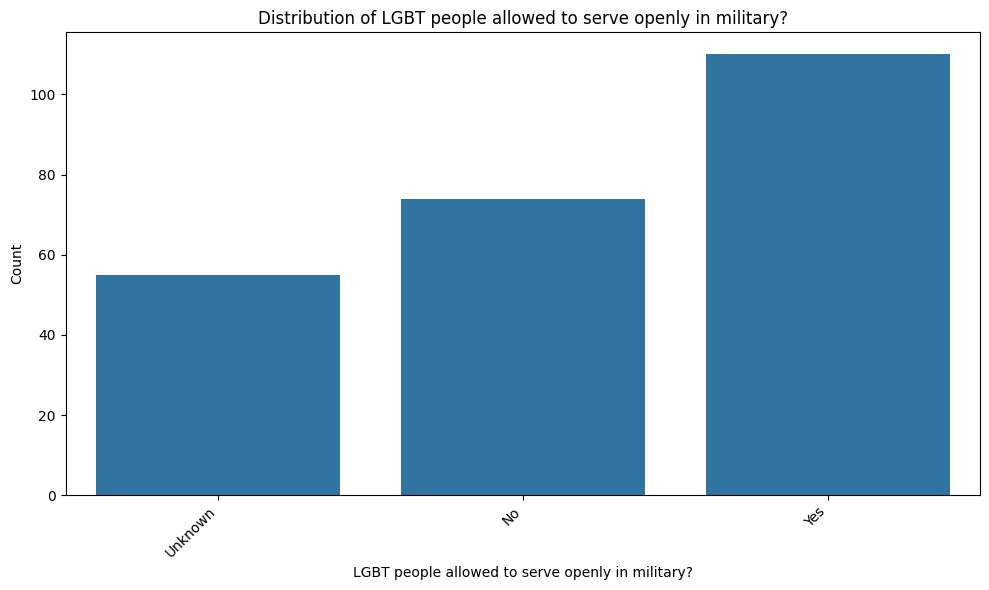

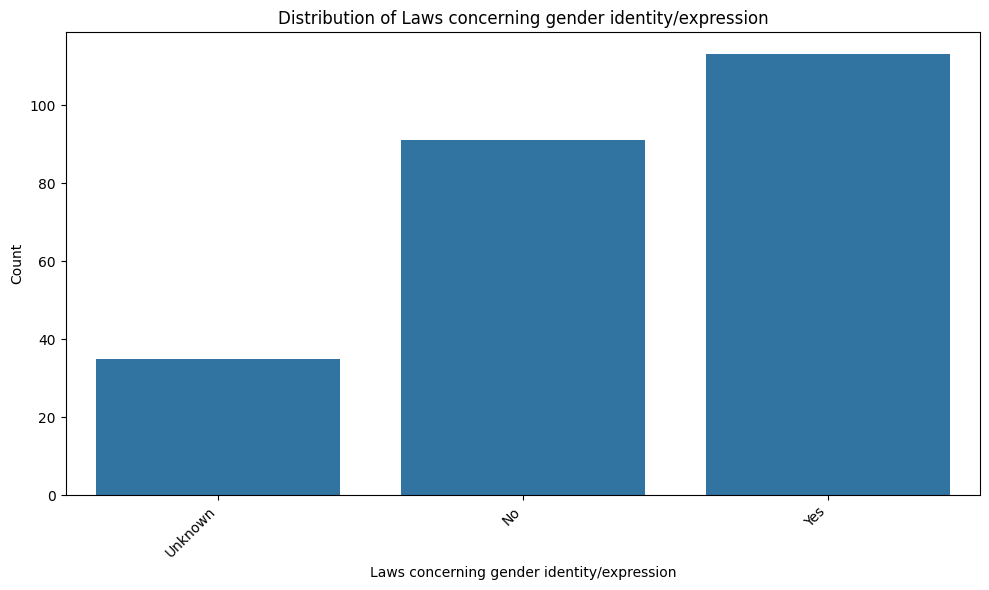

Value counts for Territory:
Territory
Georgia                  2
Kazakhstan               2
Russia                   2
Akrotiri and Dhekelia    2
Abkhazia                 2
                        ..
Fiji                     1
New Caledonia            1
Papua New Guinea         1
Solomon Islands          1
Vanuatu                  1
Name: count, Length: 227, dtype: int64

Value counts for Same-sex sexual activity:
Same-sex sexual activity
Yes        185
No          53
Unknown      1
Name: count, dtype: int64

Value counts for Recognition of same-sex unions:
Recognition of same-sex unions
No     156
Yes     83
Name: count, dtype: int64

Value counts for Adoption by same-sex couples:
Adoption by same-sex couples
No         159
Yes         73
Unknown      7
Name: count, dtype: int64

Value counts for LGBT people allowed to serve openly in military?:
LGBT people allowed to serve openly in military?
Yes        110
No          74
Unknown     55
Name: count, dtype: int64

Value counts for Law

In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

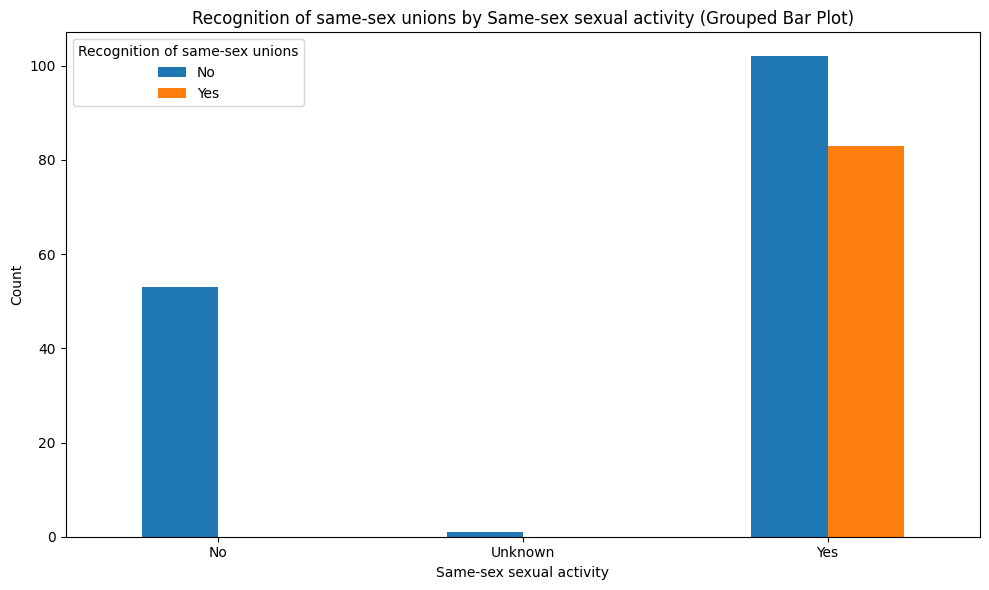

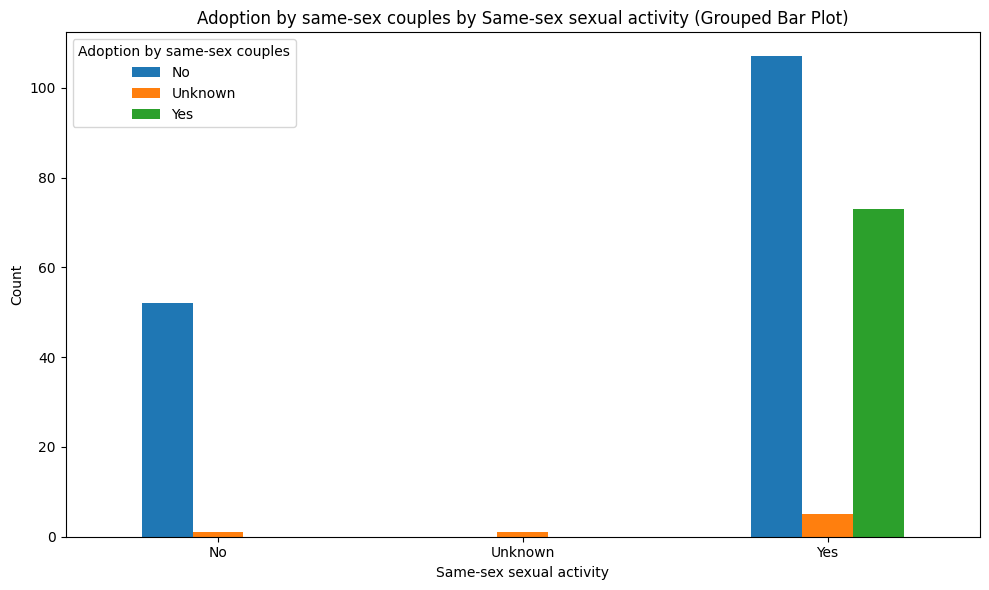

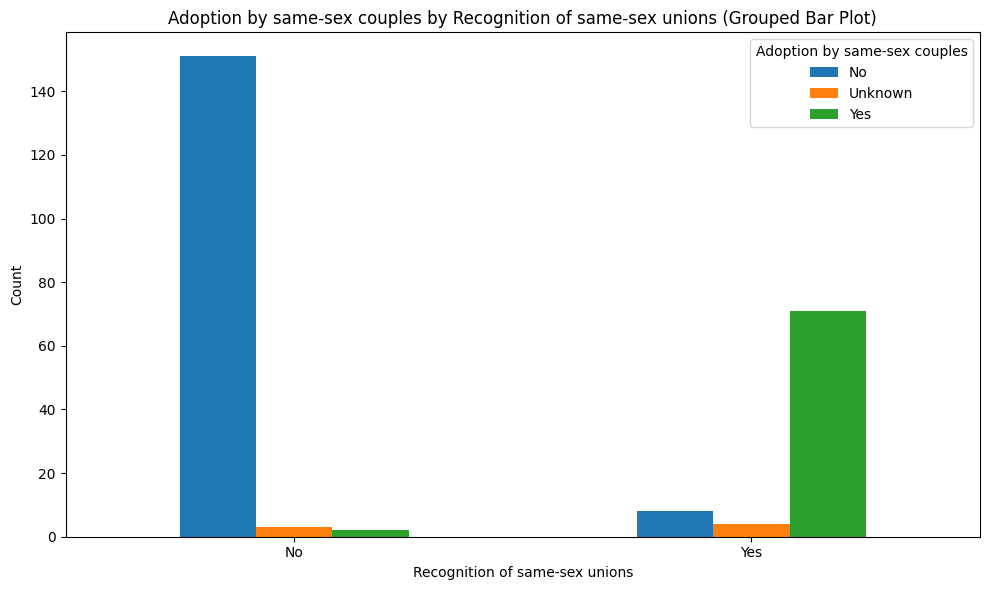

In [27]:
# Grouped bar plot 1: Recognition of same-sex unions by Same-sex sexual activity
crosstab_1 = pd.crosstab(df['Same-sex sexual activity'], df['Recognition of same-sex unions'])
crosstab_1.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Recognition of same-sex unions by Same-sex sexual activity (Grouped Bar Plot)')
plt.xlabel('Same-sex sexual activity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Grouped bar plot 2: Adoption by same-sex couples by Same-sex sexual activity
crosstab_2 = pd.crosstab(df['Same-sex sexual activity'], df['Adoption by same-sex couples'])
crosstab_2.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Adoption by same-sex couples by Same-sex sexual activity (Grouped Bar Plot)')
plt.xlabel('Same-sex sexual activity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Grouped bar plot 3: Adoption by same-sex couples by Recognition of same-sex unions
crosstab_3 = pd.crosstab(df['Recognition of same-sex unions'], df['Adoption by same-sex couples'])
crosstab_3.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Adoption by same-sex couples by Recognition of same-sex unions (Grouped Bar Plot)')
plt.xlabel('Recognition of same-sex unions')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


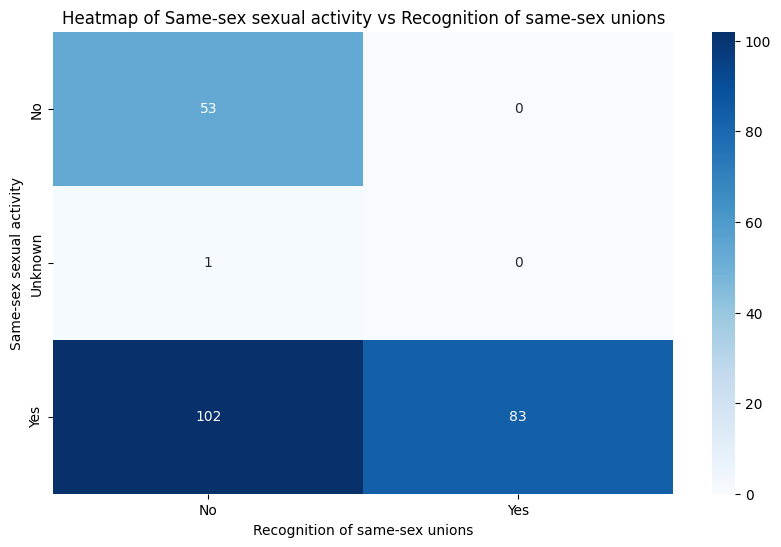

In [30]:
# Create a crosstabulation of two categorical columns
crosstab_heatmap = pd.crosstab(df['Same-sex sexual activity'], df['Recognition of same-sex unions'])

# Create a heatmap from the crosstabulation
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_heatmap, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap of Same-sex sexual activity vs Recognition of same-sex unions')
plt.xlabel('Recognition of same-sex unions')
plt.ylabel('Same-sex sexual activity')
plt.show()

# Thank you